# Advanced Sentiment Analysis using Bi-LSTM

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

In [3]:
vocab_size = 10000
max_length = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples :", len(x_test))

Training samples: 25000
Testing samples : 25000


EDA

In [11]:
print("Number of training samples:", len(x_train))
print("Number of testing samples:", len(x_test))

Number of training samples: 25000
Number of testing samples: 25000


Positive Reviews : 12500
Negative Reviews : 12500


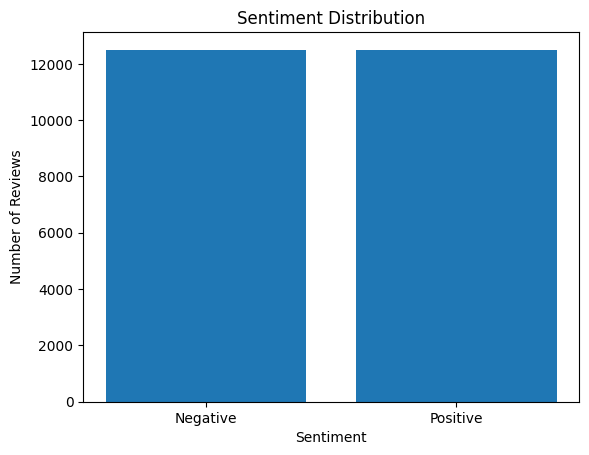

In [13]:
positive = 0
negative = 0
for label in y_train:
    if label == 1:
        positive = positive + 1
    else:
        negative = negative + 1
print("Positive Reviews :", positive)
print("Negative Reviews :", negative)
plt.bar(["Negative", "Positive"], [negative, positive])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

The dataset contains an almost equal number of positive and negative reviews.


In [15]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

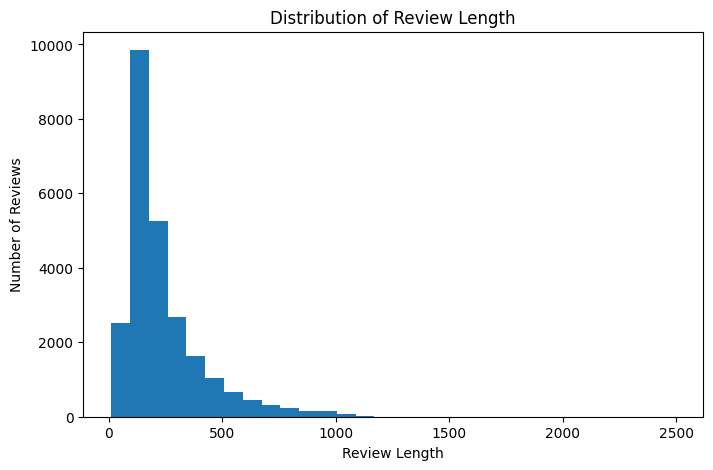

In [16]:
review_lengths = []
for review in x_train:
    length = len(review)
    review_lengths.append(length)
plt.figure(figsize=(8,5))
plt.hist(review_lengths, bins=30)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")

plt.show()

In [17]:
total_length = 0
for length in review_lengths:
    total_length = total_length + length
average_length = total_length / len(review_lengths)
print("Average Review Length :", average_length)
print("Maximum Review Length :", max(review_lengths))
print("Minimum Review Length :", min(review_lengths))

Average Review Length : 238.71364
Maximum Review Length : 2494
Minimum Review Length : 11


In [18]:
word_index = imdb.get_word_index()
reverse_word_index = {}
for word, index in word_index.items():
    reverse_word_index[index + 3] = word
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"
review = ""
for number in x_train[0]:
    review = review + reverse_word_index.get(number, "?") + " "
print(review)

if y_train[0] == 1:
    print("Sentiment : Positive")
else:
    print("Sentiment : Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these c

In [25]:
word_index = imdb.get_word_index()
reverse_word = {}
for word, index in word_index.items():
    reverse_word[index + 3] = word
reverse_word[0] = "<PAD>"
reverse_word[1] = "<START>"
reverse_word[2] = "<UNK>"
reverse_word[3] = "<UNUSED>"

In [26]:
for i in range(3):
    review = ""
    for number in x_train[i]:
        review = review + reverse_word.get(number, "?") + " "
    print("Review", i + 1)
    print(review[:600])
    print("Label :", "Positive" if y_train[i] == 1 else "Negative")
    print("=" * 80)

Review 1
and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two littl
Label : Positive
Review 2
<PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is 

In [19]:
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)


Training shape: (25000, 200)
Testing shape : (25000, 200)


# Build Bi-LSTM Model

In [5]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(1, activation="sigmoid"))
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [6]:
history = model.fit(x_train, y_train,epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 275ms/step - accuracy: 0.7582 - loss: 0.4851 - val_accuracy: 0.8436 - val_loss: 0.3672
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.8938 - loss: 0.2687 - val_accuracy: 0.8692 - val_loss: 0.3099
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 323ms/step - accuracy: 0.9280 - loss: 0.1948 - val_accuracy: 0.8696 - val_loss: 0.3331
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 305ms/step - accuracy: 0.9491 - loss: 0.1438 - val_accuracy: 0.8676 - val_loss: 0.3386
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 347ms/step - accuracy: 0.9621 - loss: 0.1112 - val_accuracy: 0.8606 - val_loss: 0.4036


# Model Evaluation

In [7]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", round(loss, 4))
print("Test Accuracy:", round(accuracy * 100, 2), "%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.8587 - loss: 0.4111
Test Loss: 0.4111
Test Accuracy: 85.87 %


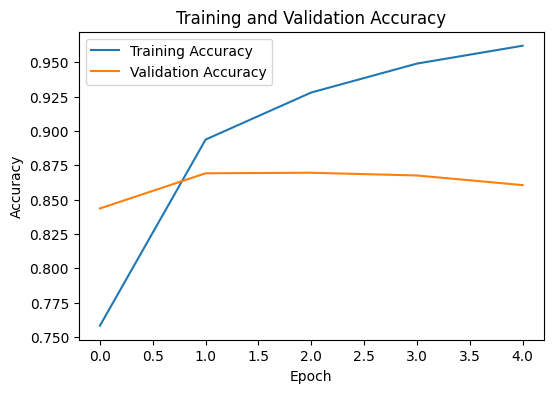

In [8]:
plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

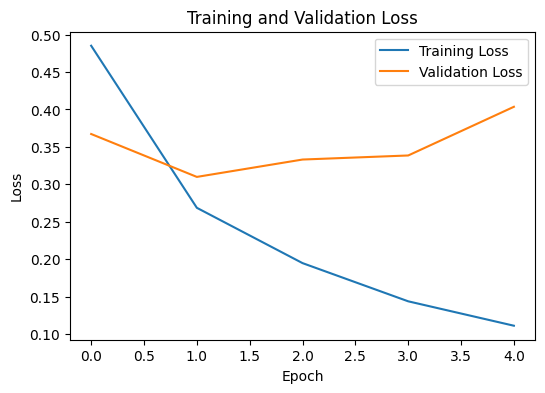

In [9]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


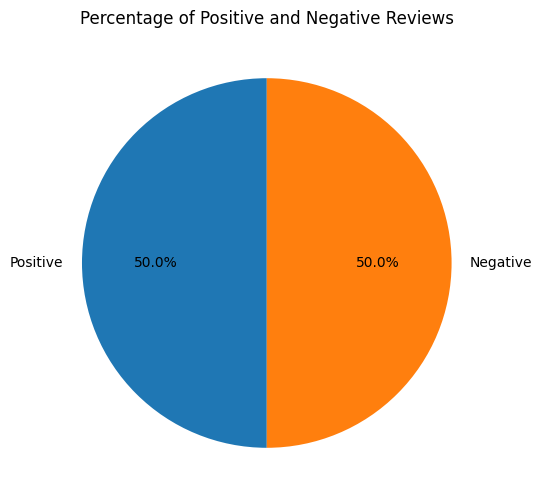

In [ ]:
positive = 0
negative = 0
for label in y_train:
    if label == 1:
        positive = positive + 1
    else:
        negative = negative + 1
labels = ["Positive", "Negative"]
sizes = [positive, negative]
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage of Positive and Negative Reviews")

plt.show()

In [27]:
predictions = model.predict(x_test[:3])
for i in range(3):
    review = ""
    for number in x_test[i]:
        word = reverse_word.get(number, "")
        if word != "<PAD>":
            review = review + word + " "
    print("Review", i + 1)
    print(review[:500])
    print()
    score = predictions[i][0]
    if score >= 0.5:
        print("Predicted : Positive")
    else:
        print("Predicted : Negative")

    if y_test[i] == 1:
        print("Actual    : Positive")
    else:
        print("Actual    : Negative")

    print("Score :", round(score, 4))
    print("=" * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Review 1
<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss 

Predicted : Negative
Actual    : Negative
Score : 0.3017
Review 2
psychological <UNK> it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident here and there i think what really makes this film work is the brilliant performance by sandy dennis it's definitely one of her darker characters but she plays it so perfectly and convincingly that it's scary michael burns does a good job as the mute young man regular altman player michael murphy has a small part the <

Predicted : Positive
Actual    : 

In [22]:
model.save("sentiment_model.keras")
print("Model saved successfully.")

Model saved successfully.
